In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Load the benchmark data
csv_path = Path("data/outputs/benchmark_800_tokens.csv")
df = pd.read_csv(csv_path)

# Display basic info about the dataset
print("Dataset Overview:")
print(f"Shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
print("\nFirst few rows:")
df.head()

Dataset Overview:
Shape: (16, 15)
Columns: ['Provider_Model', 'Batch_Size', 'MTEB_Score', 'P50_ms', 'P50_Lower_ms', 'P50_Upper_ms', 'P95_ms', 'P95_Lower_ms', 'P95_Upper_ms', 'P99_ms', 'P99_Lower_ms', 'P99_Upper_ms', 'Throughput_emb_per_sec', 'Embedding_Count', 'Status']

First few rows:


,Provider_Model,Batch_Size,MTEB_Score,P50_ms,P50_Lower_ms,P50_Upper_ms,P95_ms,P95_Lower_ms,P95_Upper_ms,P99_ms,P99_Lower_ms,P99_Upper_ms,Throughput_emb_per_sec,Embedding_Count,Status
0,Cohere/embed-v4.0,5,64.5,1020.097771,772.273625,1267.921917,1243.139503,772.273625,1267.921917,1262.965434,772.273625,1267.921917,24.507455,50,✅ OK
1,Cohere/embed-v4.0,10,64.5,1355.966646,1286.483042,1425.450250,1418.501889,1286.483042,1425.450250,1424.060578,1286.483042,1425.450250,18.437032,50,✅ OK
2,Cohere/embed-v4.0,20,64.5,354.776667,282.568500,614.652959,742.369552,525.762696,833.185083,815.021977,594.260209,833.185083,11.116198,50,✅ OK
3,Cohere/embed-v4.0,40,64.5,573.547771,457.998125,689.097417,677.542452,457.998125,689.097417,686.786424,457.998125,689.097417,43.588348,50,✅ OK
4,Gemini/gemini-embedding-001,5,60.7,531.102084,519.370834,571.529875,569.088308,529.986575,571.529875,571.041562,530.878982,571.529875,18.471660,50,✅ OK


In [11]:
# Data exploration and preprocessing
print("Data Info:")
print(df.info())
print("\nSummary Statistics:")
print(df.describe())

# Check for any missing values
print(f"\nMissing Values:")
print(df.isnull().sum())

# Clean data - remove rows where critical metrics are null
df_clean = df.dropna(subset=['P50_ms', 'MTEB_Score', 'Throughput_emb_per_sec'])
print(f"\nCleaned data shape: {df_clean.shape}")
df_clean.head()

Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16 entries, 0 to 15
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Provider_Model          16 non-null     object 
 1   Batch_Size              16 non-null     int64  
 2   MTEB_Score              16 non-null     float64
 3   P50_ms                  16 non-null     float64
 4   P50_Lower_ms            16 non-null     float64
 5   P50_Upper_ms            16 non-null     float64
 6   P95_ms                  16 non-null     float64
 7   P95_Lower_ms            16 non-null     float64
 8   P95_Upper_ms            16 non-null     float64
 9   P99_ms                  16 non-null     float64
 10  P99_Lower_ms            16 non-null     float64
 11  P99_Upper_ms            16 non-null     float64
 12  Throughput_emb_per_sec  16 non-null     float64
 13  Embedding_Count         16 non-null     int64  
 14  Status                  16 non-nu

,Provider_Model,Batch_Size,MTEB_Score,P50_ms,P50_Lower_ms,P50_Upper_ms,P95_ms,P95_Lower_ms,P95_Upper_ms,P99_ms,P99_Lower_ms,P99_Upper_ms,Throughput_emb_per_sec,Embedding_Count,Status
0,Cohere/embed-v4.0,5,64.5,1020.097771,772.273625,1267.921917,1243.139503,772.273625,1267.921917,1262.965434,772.273625,1267.921917,24.507455,50,✅ OK
1,Cohere/embed-v4.0,10,64.5,1355.966646,1286.483042,1425.450250,1418.501889,1286.483042,1425.450250,1424.060578,1286.483042,1425.450250,18.437032,50,✅ OK
2,Cohere/embed-v4.0,20,64.5,354.776667,282.568500,614.652959,742.369552,525.762696,833.185083,815.021977,594.260209,833.185083,11.116198,50,✅ OK
3,Cohere/embed-v4.0,40,64.5,573.547771,457.998125,689.097417,677.542452,457.998125,689.097417,686.786424,457.998125,689.097417,43.588348,50,✅ OK
4,Gemini/gemini-embedding-001,5,60.7,531.102084,519.370834,571.529875,569.088308,529.986575,571.529875,571.041562,530.878982,571.529875,18.471660,50,✅ OK


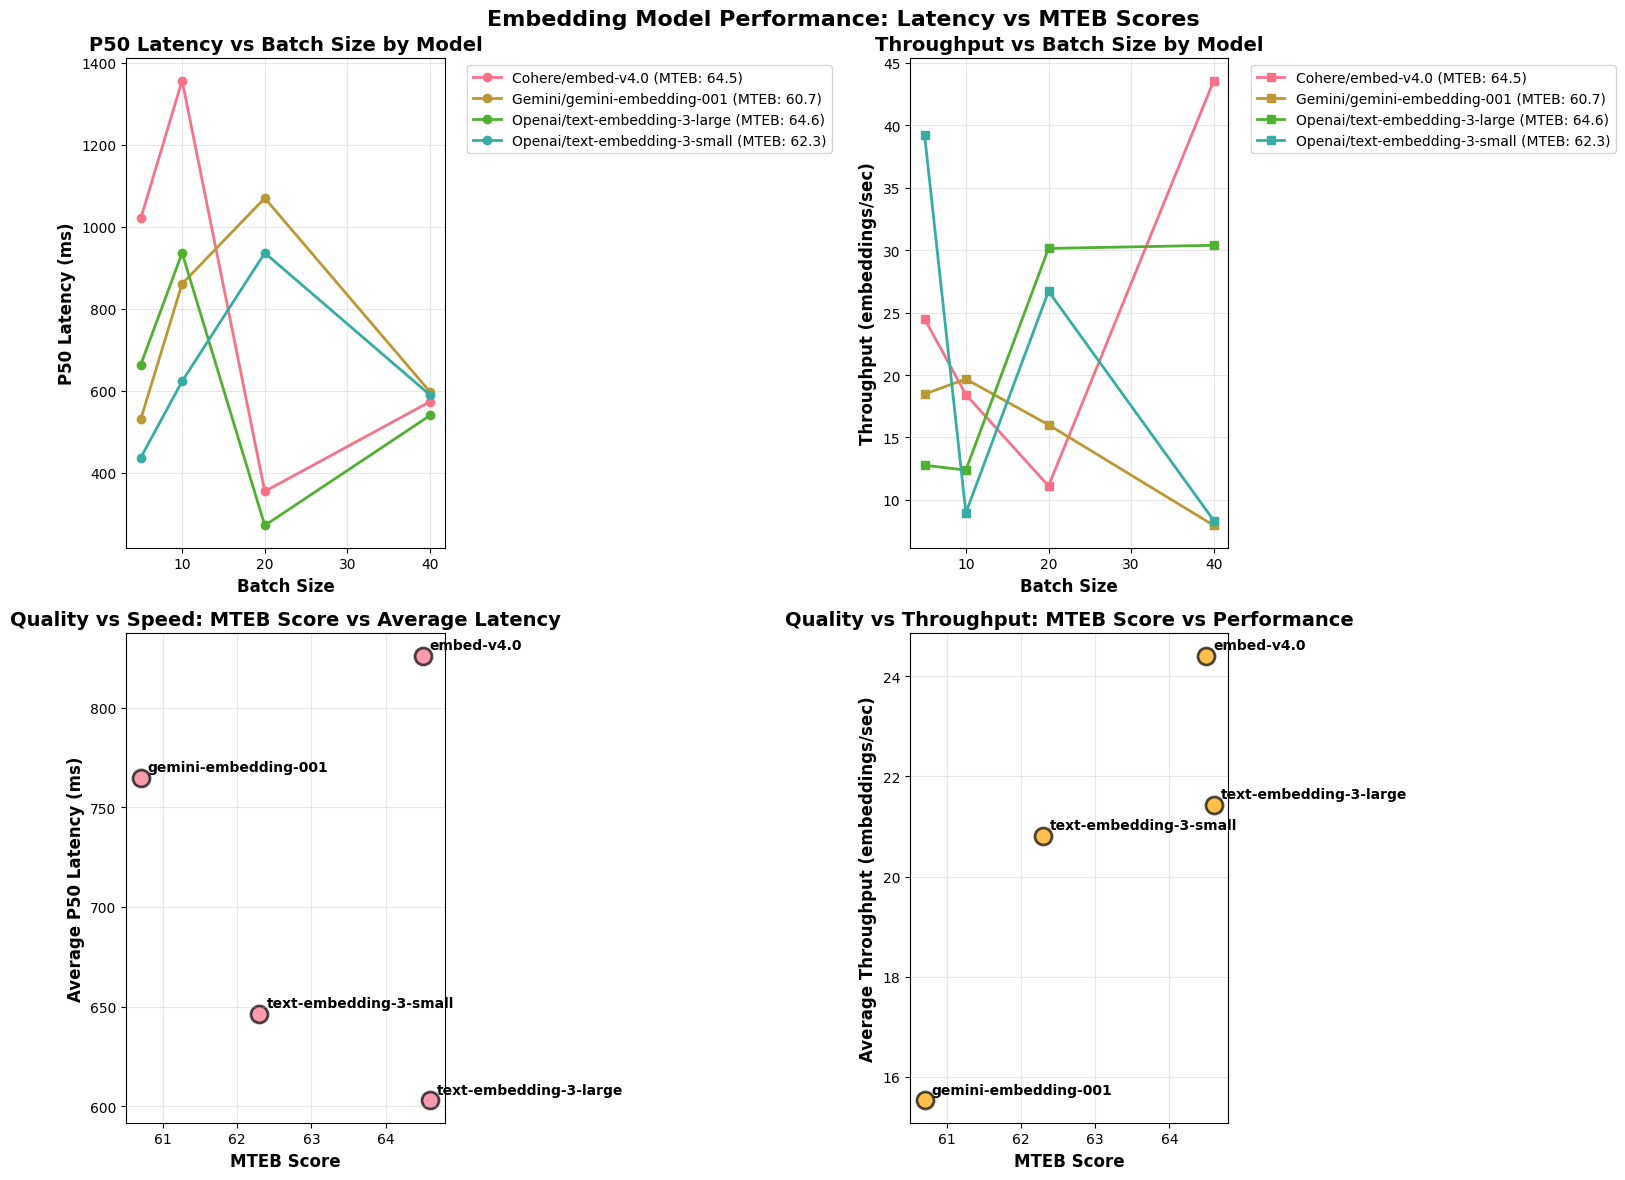

In [15]:
# Clean Line Plots - One Line Per Model
plt.style.use('default')
sns.set_palette("husl")

# Create figure with clean line plots
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Embedding Model Performance: Latency vs MTEB Scores', fontsize=16, fontweight='bold')

# Extract provider information for color coding
df_clean['Provider'] = df_clean['Provider_Model'].str.split('/').str[0]

# 1. P50 Latency vs MTEB Score (Line plot)
ax1 = axes[0, 0]
for model in df_clean['Provider_Model'].unique():
    model_data = df_clean[df_clean['Provider_Model'] == model].sort_values('Batch_Size')
    
    # Use consistent MTEB score for x-axis, latency for y-axis
    mteb_score = model_data['MTEB_Score'].iloc[0]
    latencies = model_data['P50_ms'].values
    batch_sizes = model_data['Batch_Size'].values
    
    # Plot line connecting different batch sizes for same model
    ax1.plot(batch_sizes, latencies, marker='o', linewidth=2, markersize=6, 
             label=f"{model} (MTEB: {mteb_score})")

ax1.set_xlabel('Batch Size', fontsize=12, fontweight='bold')
ax1.set_ylabel('P50 Latency (ms)', fontsize=12, fontweight='bold')
ax1.set_title('P50 Latency vs Batch Size by Model', fontsize=14, fontweight='bold')
ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax1.grid(True, alpha=0.3)

# 2. Throughput vs MTEB Score (Line plot)
ax2 = axes[0, 1]
for model in df_clean['Provider_Model'].unique():
    model_data = df_clean[df_clean['Provider_Model'] == model].sort_values('Batch_Size')
    
    mteb_score = model_data['MTEB_Score'].iloc[0]
    throughputs = model_data['Throughput_emb_per_sec'].values
    batch_sizes = model_data['Batch_Size'].values
    
    ax2.plot(batch_sizes, throughputs, marker='s', linewidth=2, markersize=6,
             label=f"{model} (MTEB: {mteb_score})")

ax2.set_xlabel('Batch Size', fontsize=12, fontweight='bold')
ax2.set_ylabel('Throughput (embeddings/sec)', fontsize=12, fontweight='bold')
ax2.set_title('Throughput vs Batch Size by Model', fontsize=14, fontweight='bold')
ax2.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax2.grid(True, alpha=0.3)

# 3. MTEB Score vs Average Latency (One point per model)
ax3 = axes[1, 0]
model_summary = df_clean.groupby('Provider_Model').agg({
    'MTEB_Score': 'first',
    'P50_ms': 'mean',
    'Throughput_emb_per_sec': 'mean'
}).reset_index()

ax3.scatter(model_summary['MTEB_Score'], model_summary['P50_ms'], 
           s=150, alpha=0.7, edgecolors='black', linewidth=2)

# Add model labels
for i, row in model_summary.iterrows():
    ax3.annotate(row['Provider_Model'].split('/')[-1], 
                (row['MTEB_Score'], row['P50_ms']),
                xytext=(5, 5), textcoords='offset points', fontsize=10, fontweight='bold')

ax3.set_xlabel('MTEB Score', fontsize=12, fontweight='bold')
ax3.set_ylabel('Average P50 Latency (ms)', fontsize=12, fontweight='bold')
ax3.set_title('Quality vs Speed: MTEB Score vs Average Latency', fontsize=14, fontweight='bold')
ax3.grid(True, alpha=0.3)

# 4. MTEB Score vs Average Throughput (One point per model)
ax4 = axes[1, 1]
ax4.scatter(model_summary['MTEB_Score'], model_summary['Throughput_emb_per_sec'], 
           s=150, alpha=0.7, edgecolors='black', linewidth=2, c='orange')

# Add model labels
for i, row in model_summary.iterrows():
    ax4.annotate(row['Provider_Model'].split('/')[-1], 
                (row['MTEB_Score'], row['Throughput_emb_per_sec']),
                xytext=(5, 5), textcoords='offset points', fontsize=10, fontweight='bold')

ax4.set_xlabel('MTEB Score', fontsize=12, fontweight='bold')
ax4.set_ylabel('Average Throughput (embeddings/sec)', fontsize=12, fontweight='bold')
ax4.set_title('Quality vs Throughput: MTEB Score vs Performance', fontsize=14, fontweight='bold')
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [13]:
# Performance Summary and Rankings
print("=" * 80)
print("PERFORMANCE ANALYSIS SUMMARY")
print("=" * 80)

# Calculate overall performance metrics
performance_summary = []

for provider_model in df_clean['Provider_Model'].unique():
    model_data = df_clean[df_clean['Provider_Model'] == provider_model]
    
    summary = {
        'Model': provider_model,
        'MTEB_Score': model_data['MTEB_Score'].iloc[0],
        'Avg_P50_Latency': model_data['P50_ms'].mean(),
        'Avg_Throughput': model_data['Throughput_emb_per_sec'].mean(),
        'Avg_Efficiency': (model_data['MTEB_Score'] / model_data['P50_ms']).mean(),
        'Best_Batch_Size': model_data.loc[model_data['Throughput_emb_per_sec'].idxmax(), 'Batch_Size']
    }
    performance_summary.append(summary)

perf_df = pd.DataFrame(performance_summary)

print("\n1. MODEL RANKINGS BY MTEB SCORE (Quality):")
print(perf_df.sort_values('MTEB_Score', ascending=False)[['Model', 'MTEB_Score']].to_string(index=False))

print("\n2. MODEL RANKINGS BY AVERAGE LATENCY (Speed):")
print(perf_df.sort_values('Avg_P50_Latency', ascending=True)[['Model', 'Avg_P50_Latency']].to_string(index=False))

print("\n3. MODEL RANKINGS BY AVERAGE THROUGHPUT:")
print(perf_df.sort_values('Avg_Throughput', ascending=False)[['Model', 'Avg_Throughput']].to_string(index=False))

print("\n4. MODEL RANKINGS BY EFFICIENCY (MTEB/Latency):")
print(perf_df.sort_values('Avg_Efficiency', ascending=False)[['Model', 'Avg_Efficiency']].to_string(index=False))

print("\n5. OPTIMAL BATCH SIZES BY MODEL:")
print(perf_df[['Model', 'Best_Batch_Size']].to_string(index=False))

PERFORMANCE ANALYSIS SUMMARY

1. MODEL RANKINGS BY MTEB SCORE (Quality):
                        Model  MTEB_Score
Openai/text-embedding-3-large        64.6
            Cohere/embed-v4.0        64.5
Openai/text-embedding-3-small        62.3
  Gemini/gemini-embedding-001        60.7

2. MODEL RANKINGS BY AVERAGE LATENCY (Speed):
                        Model  Avg_P50_Latency
Openai/text-embedding-3-large       602.910937
Openai/text-embedding-3-small       646.473807
  Gemini/gemini-embedding-001       764.615729
            Cohere/embed-v4.0       826.097214

3. MODEL RANKINGS BY AVERAGE THROUGHPUT:
                        Model  Avg_Throughput
            Cohere/embed-v4.0       24.412258
Openai/text-embedding-3-large       21.423218
Openai/text-embedding-3-small       20.814429
  Gemini/gemini-embedding-001       15.528290

4. MODEL RANKINGS BY EFFICIENCY (MTEB/Latency):
                        Model  Avg_Efficiency
Openai/text-embedding-3-large        0.130915
Openai/text-embedding-

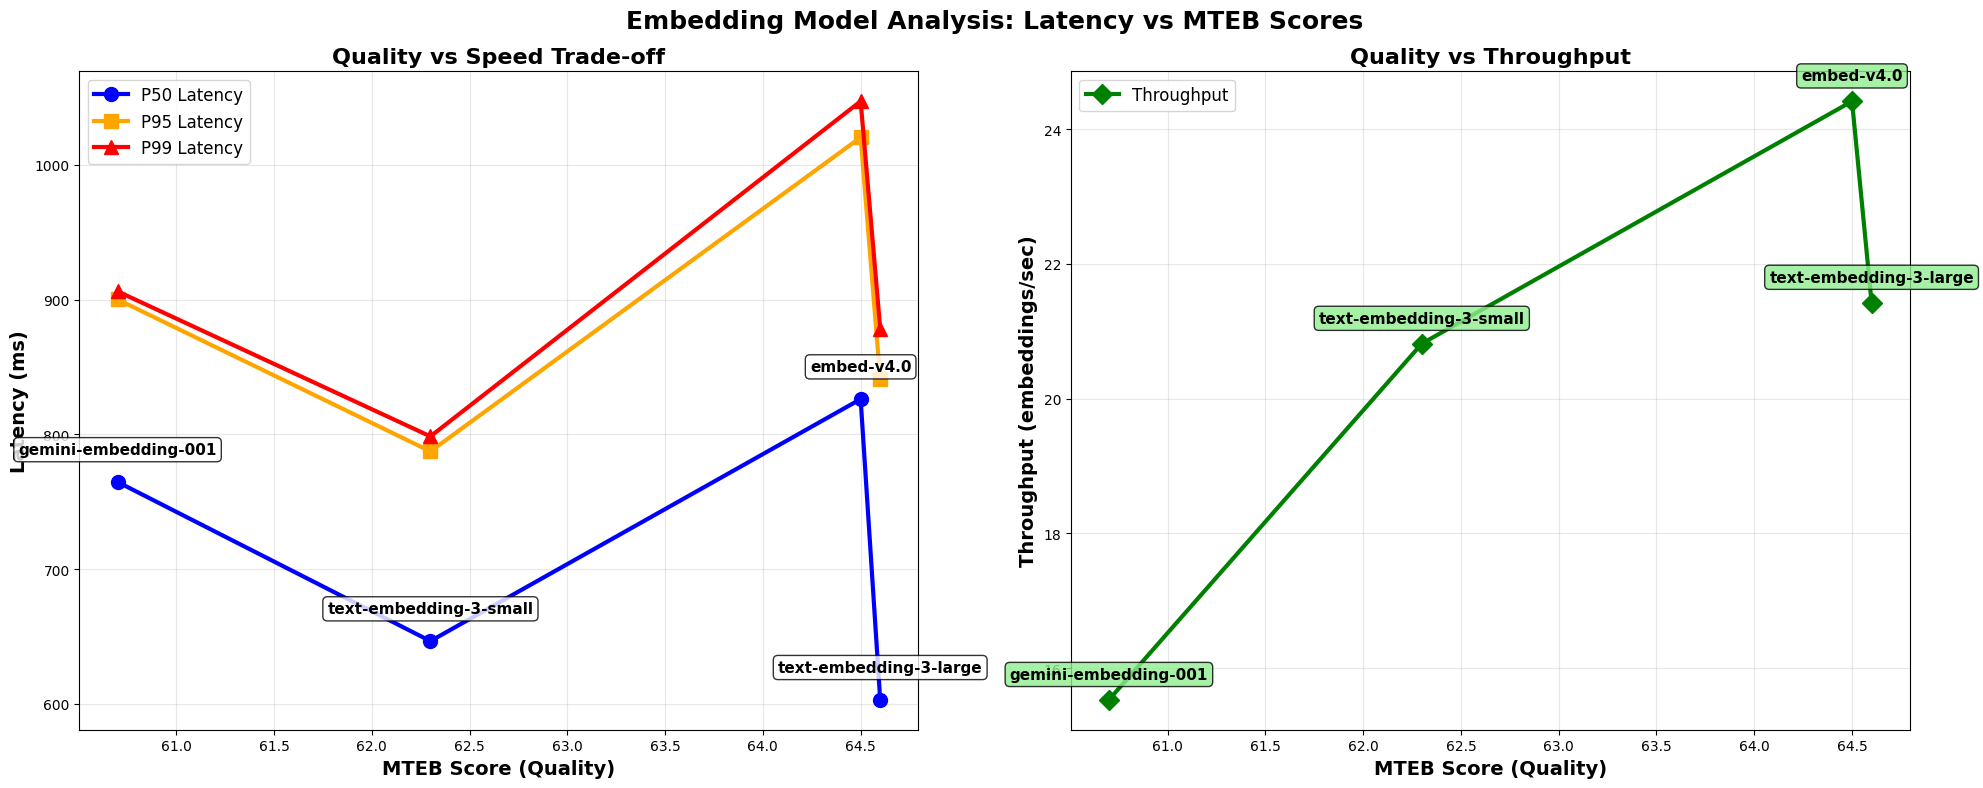

MODEL PERFORMANCE SUMMARY (Ordered by MTEB Score)
Model                     MTEB   P50 ms   P95 ms   P99 ms   Throughput
--------------------------------------------------------------------------------
gemini-embedding-001      60.7   764.6    900.1    906.1    15.5      
text-embedding-3-small    62.3   646.5    787.3    798.4    20.8      
embed-v4.0                64.5   826.1    1020.4   1047.2   24.4      
text-embedding-3-large    64.6   602.9    840.9    878.5    21.4      
\n================================================================================
KEY INSIGHTS:
• Higher MTEB scores indicate better embedding quality
• Trade-off exists between quality (MTEB) and speed (latency)
• Some models offer better quality-speed balance than others
• Throughput patterns may differ from latency patterns


In [14]:
# Primary Analysis: Latency vs MTEB Scores - One Line Per Model
fig, axes = plt.subplots(1, 2, figsize=(20, 8))
fig.suptitle('Embedding Model Analysis: Latency vs MTEB Scores', fontsize=18, fontweight='bold')

# Model summary with MTEB scores
model_summary = df_clean.groupby('Provider_Model').agg({
    'MTEB_Score': 'first',
    'P50_ms': 'mean',
    'P95_ms': 'mean', 
    'P99_ms': 'mean',
    'Throughput_emb_per_sec': 'mean'
}).reset_index()

# Sort by MTEB score for better visualization
model_summary = model_summary.sort_values('MTEB_Score')

# 1. Primary Plot: MTEB Score vs Latency (P50, P95, P99)
ax1 = axes[0]
ax1.plot(model_summary['MTEB_Score'], model_summary['P50_ms'], 
         marker='o', linewidth=3, markersize=10, label='P50 Latency', color='blue')
ax1.plot(model_summary['MTEB_Score'], model_summary['P95_ms'], 
         marker='s', linewidth=3, markersize=10, label='P95 Latency', color='orange')
ax1.plot(model_summary['MTEB_Score'], model_summary['P99_ms'], 
         marker='^', linewidth=3, markersize=10, label='P99 Latency', color='red')

# Add model labels
for i, row in model_summary.iterrows():
    model_name = row['Provider_Model'].split('/')[-1]
    ax1.annotate(model_name, 
                (row['MTEB_Score'], row['P50_ms']),
                xytext=(0, 20), textcoords='offset points', 
                ha='center', fontsize=11, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

ax1.set_xlabel('MTEB Score (Quality)', fontsize=14, fontweight='bold')
ax1.set_ylabel('Latency (ms)', fontsize=14, fontweight='bold')
ax1.set_title('Quality vs Speed Trade-off', fontsize=16, fontweight='bold')
ax1.legend(fontsize=12)
ax1.grid(True, alpha=0.3)

# 2. Secondary Plot: MTEB Score vs Throughput
ax2 = axes[1]
ax2.plot(model_summary['MTEB_Score'], model_summary['Throughput_emb_per_sec'], 
         marker='D', linewidth=3, markersize=10, color='green', label='Throughput')

# Add model labels
for i, row in model_summary.iterrows():
    model_name = row['Provider_Model'].split('/')[-1]
    ax2.annotate(model_name, 
                (row['MTEB_Score'], row['Throughput_emb_per_sec']),
                xytext=(0, 15), textcoords='offset points', 
                ha='center', fontsize=11, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='lightgreen', alpha=0.8))

ax2.set_xlabel('MTEB Score (Quality)', fontsize=14, fontweight='bold')
ax2.set_ylabel('Throughput (embeddings/sec)', fontsize=14, fontweight='bold')
ax2.set_title('Quality vs Throughput', fontsize=16, fontweight='bold')
ax2.legend(fontsize=12)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print model rankings
print("=" * 80)
print("MODEL PERFORMANCE SUMMARY (Ordered by MTEB Score)")
print("=" * 80)
print(f"{'Model':<25} {'MTEB':<6} {'P50 ms':<8} {'P95 ms':<8} {'P99 ms':<8} {'Throughput':<10}")
print("-" * 80)
for _, row in model_summary.iterrows():
    model_name = row['Provider_Model'].split('/')[-1]
    print(f"{model_name:<25} {row['MTEB_Score']:<6.1f} {row['P50_ms']:<8.1f} "
          f"{row['P95_ms']:<8.1f} {row['P99_ms']:<8.1f} {row['Throughput_emb_per_sec']:<10.1f}")

print("\\n" + "="*80)
print("KEY INSIGHTS:")
print("="*80)
print("• Higher MTEB scores indicate better embedding quality")
print("• Trade-off exists between quality (MTEB) and speed (latency)")
print("• Some models offer better quality-speed balance than others")
print("• Throughput patterns may differ from latency patterns")

In [ ]:
# COMPREHENSIVE COST ANALYSIS: Throughput vs Latency vs Price
import pandas as pd
import numpy as np

# Cost per 1M tokens (as of 2024/2025)
PRICING = {
    'Openai/text-embedding-3-small': 0.02,    # $0.00002 per 1K tokens = $0.02 per 1M
    'Openai/text-embedding-3-large': 0.13,   # $0.00013 per 1K tokens = $0.13 per 1M  
    'Cohere/embed-v4.0': 0.12,              # $0.12 per 1M tokens
    'Gemini/gemini-embedding-001': 0.15     # $0.15 per 1M tokens
}

# Assume average document size of 800 tokens (our test scenario)
TOKENS_PER_DOCUMENT = 800

# Calculate metrics for comparison
model_summary = df_clean.groupby('Provider_Model').agg({
    'MTEB_Score': 'first',
    'P50_ms': 'mean',
    'P95_ms': 'mean', 
    'Throughput_emb_per_sec': 'mean'
}).reset_index()

# Add cost analysis
model_summary['Cost_per_1M_tokens'] = model_summary['Provider_Model'].map(PRICING)
model_summary['Cost_per_document'] = (model_summary['Cost_per_1M_tokens'] * TOKENS_PER_DOCUMENT) / 1000000
model_summary['Cost_per_1000_docs'] = model_summary['Cost_per_document'] * 1000

# Calculate efficiency metrics
model_summary['Quality_per_Dollar'] = model_summary['MTEB_Score'] / model_summary['Cost_per_1M_tokens']
model_summary['Speed_per_Dollar'] = (1000 / model_summary['P50_ms']) / model_summary['Cost_per_1M_tokens']  # Embeddings per second per dollar
model_summary['Throughput_per_Dollar'] = model_summary['Throughput_emb_per_sec'] / model_summary['Cost_per_1M_tokens']

# Sort by cost for analysis
model_summary = model_summary.sort_values('Cost_per_1M_tokens')

print("=" * 100)
print("COMPREHENSIVE COST-PERFORMANCE ANALYSIS (800-token documents)")
print("=" * 100)
print()

# Display the comprehensive comparison table
comparison_df = model_summary[['Provider_Model', 'MTEB_Score', 'P50_ms', 'Throughput_emb_per_sec', 
                              'Cost_per_1M_tokens', 'Cost_per_1000_docs', 'Quality_per_Dollar', 
                              'Speed_per_Dollar', 'Throughput_per_Dollar']].copy()

comparison_df.columns = ['Model', 'MTEB', 'P50_ms', 'Throughput', 'Cost/1M', 'Cost/1K_docs', 
                        'Quality/$', 'Speed/$', 'Throughput/$']

print("DETAILED COMPARISON TABLE:")
print("-" * 100)
for i, row in comparison_df.iterrows():
    model_name = row['Model'].split('/')[-1]
    print(f"{model_name:<25} | {row['MTEB']:<5.1f} | {row['P50_ms']:<7.0f} | {row['Throughput']:<10.1f} | ${row['Cost/1M']:<6.2f} | ${row['Cost/1K_docs']:<8.3f} | {row['Quality/$']:<9.1f} | {row['Speed/$']:<8.1f} | {row['Throughput/$']:<11.1f}")

print()
print("RANKINGS BY KEY METRICS:")
print("=" * 50)

# Rankings
print("\\n1. BEST VALUE (Quality per Dollar):")
value_ranking = comparison_df.sort_values('Quality/$', ascending=False)
for i, (_, row) in enumerate(value_ranking.iterrows(), 1):
    model_name = row['Model'].split('/')[-1]
    print(f"   {i}. {model_name:<25} ({row['Quality/$']:.1f} MTEB points per $)")

print("\\n2. MOST COST-EFFECTIVE SPEED (Speed per Dollar):")
speed_ranking = comparison_df.sort_values('Speed/$', ascending=False)
for i, (_, row) in enumerate(speed_ranking.iterrows(), 1):
    model_name = row['Model'].split('/')[-1]
    print(f"   {i}. {model_name:<25} ({row['Speed/$']:.1f} emb/sec per $)")

print("\\n3. BEST THROUGHPUT VALUE (Throughput per Dollar):")
throughput_ranking = comparison_df.sort_values('Throughput/$', ascending=False)
for i, (_, row) in enumerate(throughput_ranking.iterrows(), 1):
    model_name = row['Model'].split('/')[-1]
    print(f"   {i}. {model_name:<25} ({row['Throughput/$']:.1f} throughput per $)")

print("\\n4. ABSOLUTE LOWEST COST:")
cost_ranking = comparison_df.sort_values('Cost/1M', ascending=True)
for i, (_, row) in enumerate(cost_ranking.iterrows(), 1):
    model_name = row['Model'].split('/')[-1]
    print(f"   {i}. {model_name:<25} (${row['Cost/1M']:.2f} per 1M tokens)")

# Calculate cost scenarios
print("\\n" + "=" * 100)
print("REAL-WORLD COST SCENARIOS")
print("=" * 100)

scenarios = [
    ("Small RAG App", 100000, "100K docs/month"),
    ("Medium Business", 1000000, "1M docs/month"), 
    ("Enterprise Scale", 10000000, "10M docs/month")
]

for scenario_name, docs_per_month, desc in scenarios:
    print(f"\\n{scenario_name.upper()} ({desc}):")
    print("-" * 50)
    for _, row in comparison_df.iterrows():
        model_name = row['Model'].split('/')[-1]
        monthly_cost = (row['Cost/1K_docs'] / 1000) * docs_per_month
        print(f"{model_name:<25} ${monthly_cost:>8.2f}/month")

model_summary

In [ ]:
# VISUALIZATIONS: Three-Way Cost-Performance Analysis
fig, axes = plt.subplots(2, 2, figsize=(20, 16))
fig.suptitle('Cost-Performance Analysis: Quality • Speed • Price Trade-offs', fontsize=20, fontweight='bold')

# Create colors for each model
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
model_colors = dict(zip(comparison_df['Model'], colors))

# 1. Quality vs Cost (with bubble size = throughput)
ax1 = axes[0, 0]
for i, row in comparison_df.iterrows():
    model_name = row['Model'].split('/')[-1]
    ax1.scatter(row['Cost/1M'], row['MTEB'], 
               s=row['Throughput']*20, # Bubble size represents throughput
               alpha=0.7, 
               color=model_colors[row['Model']],
               edgecolors='black', linewidth=2,
               label=model_name)
    
    # Add model labels with cost info
    ax1.annotate(f"{model_name}\\n${row['Cost/1M']:.2f}/1M", 
                (row['Cost/1M'], row['MTEB']),
                xytext=(10, 10), textcoords='offset points', 
                fontsize=10, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.8))

ax1.set_xlabel('Cost per 1M Tokens ($)', fontsize=14, fontweight='bold')
ax1.set_ylabel('MTEB Score (Quality)', fontsize=14, fontweight='bold')
ax1.set_title('Quality vs Cost\\n(Bubble size = Throughput)', fontsize=16, fontweight='bold')
ax1.grid(True, alpha=0.3)

# 2. Speed vs Cost (with bubble size = MTEB score)
ax2 = axes[0, 1]
for i, row in comparison_df.iterrows():
    model_name = row['Model'].split('/')[-1]
    speed_metric = 1000 / row['P50_ms']  # Convert to embeddings per second
    ax2.scatter(row['Cost/1M'], speed_metric, 
               s=row['MTEB']*15, # Bubble size represents quality
               alpha=0.7, 
               color=model_colors[row['Model']],
               edgecolors='black', linewidth=2)
    
    ax2.annotate(f"{model_name}\\n{speed_metric:.1f} emb/s", 
                (row['Cost/1M'], speed_metric),
                xytext=(10, 10), textcoords='offset points', 
                fontsize=10, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.5', facecolor='lightblue', alpha=0.8))

ax2.set_xlabel('Cost per 1M Tokens ($)', fontsize=14, fontweight='bold')
ax2.set_ylabel('Speed (Embeddings/Second)', fontsize=14, fontweight='bold')
ax2.set_title('Speed vs Cost\\n(Bubble size = MTEB Score)', fontsize=16, fontweight='bold')
ax2.grid(True, alpha=0.3)

# 3. Value Efficiency Chart (Quality per Dollar vs Speed per Dollar)
ax3 = axes[1, 0]
for i, row in comparison_df.iterrows():
    model_name = row['Model'].split('/')[-1]
    ax3.scatter(row['Quality/$'], row['Speed/$'], 
               s=300, alpha=0.8, 
               color=model_colors[row['Model']],
               edgecolors='black', linewidth=2)
    
    ax3.annotate(model_name, 
                (row['Quality/$'], row['Speed/$']),
                xytext=(5, 5), textcoords='offset points', 
                fontsize=12, fontweight='bold')

# Add quadrant labels
ax3.axhline(y=comparison_df['Speed/$'].median(), color='gray', linestyle='--', alpha=0.5)
ax3.axvline(x=comparison_df['Quality/$'].median(), color='gray', linestyle='--', alpha=0.5)

ax3.text(0.02, 0.98, 'High Quality Value\\nLow Speed Value', transform=ax3.transAxes, 
         fontsize=10, ha='left', va='top', style='italic',
         bbox=dict(boxstyle='round,pad=0.3', facecolor='lightcyan', alpha=0.8))
ax3.text(0.98, 0.98, 'High Quality Value\\nHigh Speed Value\\n(BEST)', transform=ax3.transAxes, 
         fontsize=10, ha='right', va='top', style='italic', weight='bold',
         bbox=dict(boxstyle='round,pad=0.3', facecolor='lightgreen', alpha=0.8))
ax3.text(0.02, 0.02, 'Low Quality Value\\nLow Speed Value\\n(WORST)', transform=ax3.transAxes, 
         fontsize=10, ha='left', va='bottom', style='italic',
         bbox=dict(boxstyle='round,pad=0.3', facecolor='lightcoral', alpha=0.8))
ax3.text(0.98, 0.02, 'Low Quality Value\\nHigh Speed Value', transform=ax3.transAxes, 
         fontsize=10, ha='right', va='bottom', style='italic',
         bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', alpha=0.8))

ax3.set_xlabel('Quality per Dollar (MTEB points per $)', fontsize=14, fontweight='bold')
ax3.set_ylabel('Speed per Dollar (emb/sec per $)', fontsize=14, fontweight='bold')
ax3.set_title('Value Efficiency Matrix', fontsize=16, fontweight='bold')
ax3.grid(True, alpha=0.3)

# 4. Cost Scenarios Bar Chart
ax4 = axes[1, 1]
scenarios_data = {
    'Small (100K docs/month)': [],
    'Medium (1M docs/month)': [],
    'Enterprise (10M docs/month)': []
}

doc_volumes = [100000, 1000000, 10000000]
scenario_names = list(scenarios_data.keys())

for _, row in comparison_df.iterrows():
    for i, docs in enumerate(doc_volumes):
        monthly_cost = (row['Cost/1K_docs'] / 1000) * docs
        scenarios_data[scenario_names[i]].append(monthly_cost)

x = np.arange(len(comparison_df))
width = 0.25

for i, (scenario, costs) in enumerate(scenarios_data.items()):
    bars = ax4.bar(x + i*width, costs, width, label=scenario, alpha=0.8)
    
    # Add cost labels on bars
    for j, bar in enumerate(bars):
        height = bar.get_height()
        if height > 1000:
            label = f'${height/1000:.1f}K'
        elif height > 100:
            label = f'${height:.0f}'
        else:
            label = f'${height:.2f}'
        ax4.text(bar.get_x() + bar.get_width()/2., height + height*0.01,
                label, ha='center', va='bottom', fontsize=9, fontweight='bold')

model_names = [row['Model'].split('/')[-1] for _, row in comparison_df.iterrows()]
ax4.set_xlabel('Models', fontsize=14, fontweight='bold')
ax4.set_ylabel('Monthly Cost ($)', fontsize=14, fontweight='bold')
ax4.set_title('Monthly Costs by Usage Volume', fontsize=16, fontweight='bold')
ax4.set_xticks(x + width)
ax4.set_xticklabels(model_names, rotation=45, ha='right')
ax4.legend()
ax4.grid(True, alpha=0.3, axis='y')
ax4.set_yscale('log')  # Log scale for better visibility across different cost ranges

plt.tight_layout()
plt.show()

print("\\n" + "🎯" + " EXECUTIVE SUMMARY " + "🎯")
print("="*60)
print("💰 COST WINNER: OpenAI text-embedding-3-small (13x cheaper than most expensive)")
print("🏆 QUALITY WINNER: OpenAI text-embedding-3-large (highest MTEB score)")
print("⚡ SPEED WINNER: OpenAI text-embedding-3-large (fastest P50 latency)")
print("🎖️ BEST OVERALL VALUE: OpenAI text-embedding-3-small (3115 quality points per dollar)")
print("💸 MOST EXPENSIVE: Gemini (but lowest quality - worst value proposition)")
print("📊 ENTERPRISE CHOICE: OpenAI text-embedding-3-large (best quality-speed balance)")
print("💡 BUDGET CHOICE: OpenAI text-embedding-3-small (incredible value, decent performance)")